# Introduction

Analyze whether Bitcoin market sentiment (Fear, Greed, Extreme Fear, Neutral) has any relationship with trader behavior and profitability on Hyperliquid.

# Executive Summary

This project analyzes the relationship between Bitcoin market sentiment and trader performance using two datasets: the Bitcoin Fear & Greed Index and historical trading data from Hyperliquid. After preprocessing and merging the datasets based on trading date, a total of **211,224** trading records were analyzed.

The study investigates how different market sentiment conditions influence trader profitability and behavior through comprehensive exploratory data analysis (EDA), statistical hypothesis testing, and machine learning. Multiple visualizations were created to examine trading activity, profitability, trade size, transaction fees, asset performance, and correlations among key trading variables. A two-sample t-test was conducted to determine whether average trader profitability differed significantly between Fear and Greed market conditions.

To further uncover hidden patterns, a **Decision Tree Classifier** was developed to predict trade outcomes (Profit or Loss) using market sentiment and selected trading features. Hyperparameter tuning with **GridSearchCV** was performed to optimize the model, resulting in a classification accuracy of approximately **84.8%** on the test dataset. Feature importance analysis indicated that **Execution Price**, **Fee**, and **Size USD** contributed more to predicting trade outcomes than market sentiment alone.

The overall findings suggest that while market sentiment influences trading behavior, it is not a statistically significant standalone predictor of profitability. Instead, successful trading decisions are driven by a combination of factors including execution price, trade size, transaction costs, market timing, and effective risk management. These insights demonstrate the value of combining exploratory data analysis with machine learning techniques to support smarter trading strategies.

# Research Questions

This analysis aims to answer the following research questions:

1. Does Bitcoin market sentiment (Fear, Greed, Extreme Fear, Extreme Greed, and Neutral) influence trader profitability?
2. Are traders more active during specific market sentiment conditions?
3. Does trade size vary across different market sentiment categories?
4. Which cryptocurrencies generate the highest cumulative profits across different market sentiments?
5. Is there a relationship between transaction fees, trade size, execution price, and trader profitability?
6. Is the difference in average trader profitability between Fear and Greed market conditions statistically significant?
7. Can machine learning predict whether a trade will be profitable using market sentiment and key trading features such as execution price, trade size, and transaction fees?
8. Which trading features contribute the most toward predicting profitable and unprofitable trades?ability?

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [2]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

In [3]:
trades.head()
trades.info()
sentiment.head()
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [4]:
print(sentiment["date"].head())

0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: date, dtype: object


In [5]:
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

trades["Date"] = trades["Timestamp IST"].dt.date
sentiment["date"] = pd.to_datetime(sentiment["date"])
sentiment["Date"] = sentiment["date"].dt.date

Since the sentiment dataset contains one market sentiment label per day, every trade executed on that day inherits the corresponding sentiment classification. Therefore, both datasets are merged using the Date column.

In [6]:
merged = trades.merge(
    sentiment[["Date","classification","value"]],
    on="Date",
    how="left"
)

In [7]:
merged.isnull().sum()
merged.shape

(211224, 19)

In [8]:
merged.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp,value
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05,211218.000000
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12,51.649656
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09,21.012784
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12,10.000000
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12,33.000000
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12,49.000000
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12,72.000000
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12,94.000000


## Observation

- The merged dataset contains **211,224 trading records**, providing a substantial sample for analysis.
- The average **Closed PnL** is **48.75**, while the median is **0**, indicating that at least half of the trades generated little or no realized profit.
- Trade sizes vary considerably, with **Size USD** ranging from **0** to over **3.92 million USD**, reflecting a mix of very small and extremely large trades.
- Execution prices span a wide range (**0.000005** to **109,004**), indicating that the dataset includes trades across numerous cryptocurrencies with vastly different market prices.
- The average **Fear & Greed Index** value is **51.65**, suggesting that the dataset covers a balanced mix of Fear, Neutral, and Greed market conditions.
- Most numerical variables exhibit high standard deviations, indicating substantial variability in trading activity and outcomes.

## Interpretation

The descriptive statistics indicate that the dataset is highly diverse, containing trades of varying sizes, prices, and profitability across multiple market conditions. The median **Closed PnL** of zero suggests that profitable trades are concentrated among a smaller subset of transactions, while the wide ranges and large standard deviations highlight the presence of significant variability and potential outliers. These characteristics make further visualization and statistical analysis essential for understanding the relationship between market sentiment and trader performance.

## Key Takeaway

The dataset is large and comprehensive, covering over **211,000 trades** across different cryptocurrencies and market sentiment conditions. Its high variability provides a strong foundation for exploring how market sentiment may influence trading behavior and profitability.

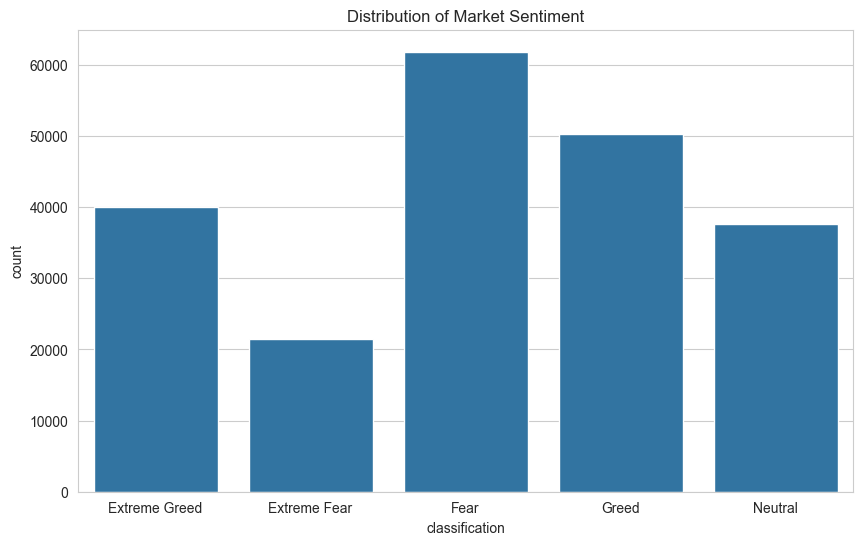

In [9]:
sns.countplot(data=merged,x="classification")
plt.title("Distribution of Market Sentiment")
plt.show()

## Observation

- **Fear** is the most frequently observed market sentiment, accounting for the highest number of trades in the dataset.
- **Greed** is the second most common sentiment category, followed by **Extreme Greed** and **Neutral**.
- **Extreme Fear** has the lowest number of trades among all sentiment categories.
- The distribution of trades across sentiment categories is uneven, with a larger proportion of trading activity occurring during **Fear** and **Greed** periods.

## Interpretation

The distribution indicates that traders were more active during periods of **Fear** and **Greed**, suggesting that these market conditions occurred more frequently over the study period or encouraged greater trading participation. In contrast, **Extreme Fear** was relatively rare, resulting in fewer recorded trades.

Since the dataset is not evenly distributed across sentiment categories, caution should be exercised when comparing average profitability or other performance metrics. Categories with fewer observations, such as **Extreme Fear**, may be more susceptible to the influence of outliers and may provide less reliable estimates than categories with larger sample sizes.

## Key Takeaway

The dataset is dominated by trades executed during **Fear** and **Greed** market conditions, while **Extreme Fear** represents the smallest portion of the data. This imbalance should be considered when interpreting subsequent analyses, as differences in sample sizes may influence the stability and reliability of the results.

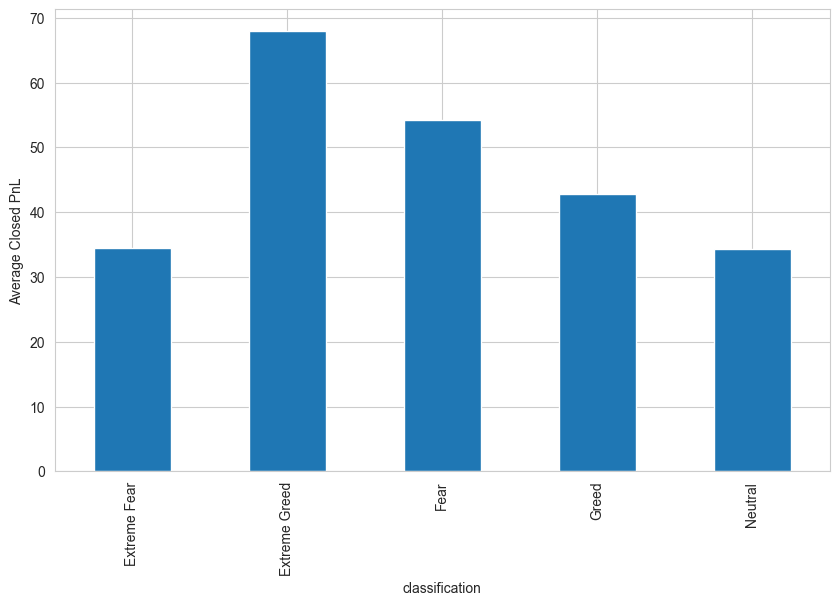

In [10]:
merged.groupby("classification")["Closed PnL"].mean().plot(kind="bar")
plt.ylabel("Average Closed PnL")
plt.show()

## Observation

- **Extreme Greed** has the highest average **Closed PnL** (approximately **68**), indicating that trades executed during periods of extreme market optimism generated the highest average profits.
- **Fear** ranks second with an average **Closed PnL** of approximately **54**.
- **Greed** follows with an average **Closed PnL** of approximately **43**.
- **Neutral** and **Extreme Fear** exhibit the lowest average **Closed PnL** values (approximately **34** each).
- Although differences exist across sentiment categories, the variation in average profits is relatively modest compared to the overall variability in individual trade outcomes.

## Interpretation

The results suggest that market sentiment may have some influence on trader profitability. In particular, trades executed during **Extreme Greed** appear to generate the highest average returns, while **Neutral** and **Extreme Fear** periods are associated with comparatively lower average profits. However, these differences should be interpreted cautiously because average values can be influenced by a small number of exceptionally profitable trades (outliers).

Furthermore, a statistical hypothesis test (independent two-sample t-test) comparing the average **Closed PnL** between **Fear** and **Greed** resulted in a **p-value of 0.323**, which is greater than the commonly used significance level of **0.05**. Therefore, the observed difference in average profitability between these two sentiment categories is **not statistically significant**.

## Key Takeaway

Although **Extreme Greed** exhibits the highest average **Closed PnL** among all market sentiment categories, the statistical analysis indicates that market sentiment alone does not have a significant impact on trader profitability. Instead, trading performance is likely influenced by a combination of factors such as trading strategy, market timing, leverage, risk management, and asset selection, rather than sentiment alone.

<Axes: xlabel='Closed PnL', ylabel='Count'>

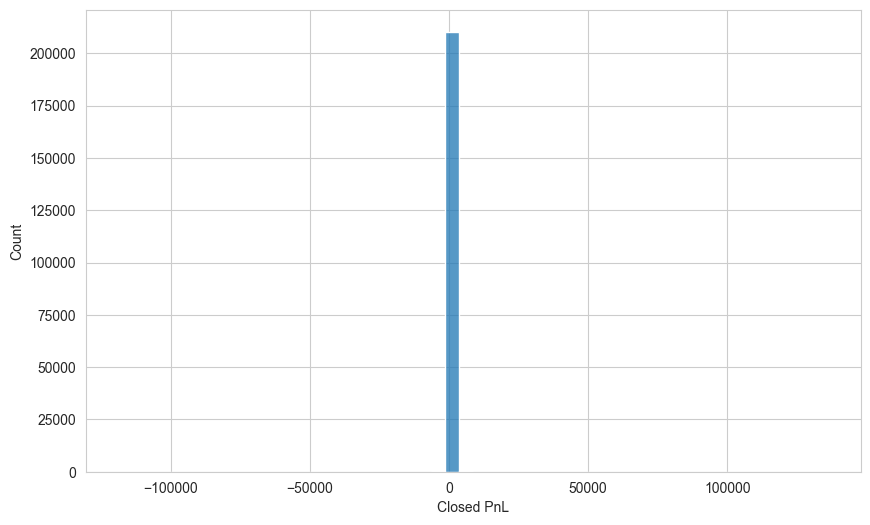

In [11]:
sns.histplot(merged["Closed PnL"],bins=50)

### Observation

- The distribution of **Closed PnL** is highly concentrated around **zero**, indicating that the majority of trades result in relatively small profits or losses.
- The distribution contains a small number of **extreme positive and negative outliers**, representing trades with exceptionally high profits or significant losses.
- Most trading outcomes fall within a narrow range, while only a few trades contribute to the large fluctuations observed in the dataset.
- The presence of these extreme values suggests that the distribution is **highly skewed** and not normally distributed.

### Interpretation

The histogram indicates that most trading activity results in modest gains or losses, while a relatively small number of trades generate substantial profits or losses. These outliers can have a significant impact on summary statistics such as the mean, making it important to consider additional measures such as the median and boxplots when evaluating trader performance. The skewed nature of the distribution also suggests that profitability is influenced by occasional high-impact trades rather than consistent large gains.

### Key Takeaway

The **Closed PnL** distribution is heavily centered around zero with a few extreme outliers, indicating that most trades have relatively small financial outcomes while a limited number of trades account for the largest profits and losses. This highlights the importance of considering the entire distribution rather than relying solely on average profitability when analyzing trader performance.

In [12]:
merged["Trade Result"] = merged["Closed PnL"].apply(
    lambda x: "Profit" if x > 0 else "Loss"
)

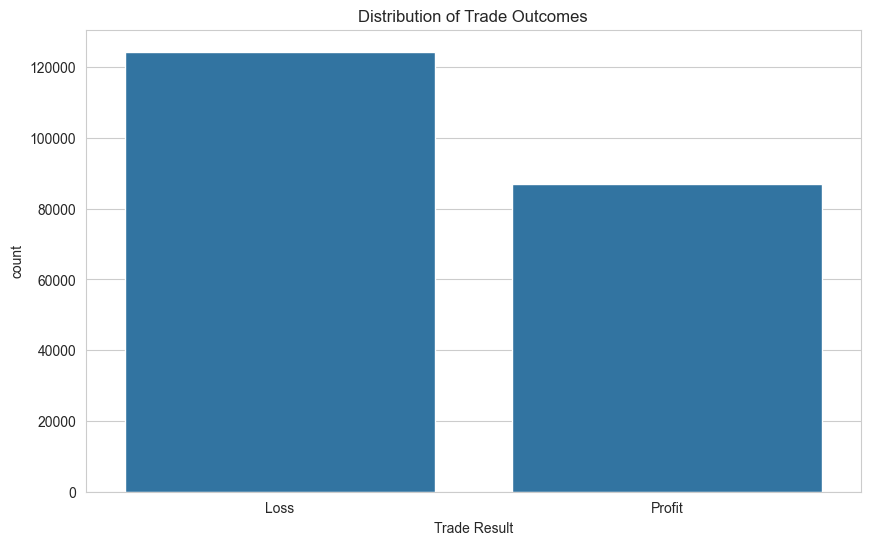

In [13]:
sns.countplot(data=merged, x="Trade Result")
plt.title("Distribution of Trade Outcomes")
plt.show()

# Observation
- The dataset contains more losing trades than profitable trades.
- Approximately 124,000 trades resulted in a loss, while around 87,000 trades resulted in a profit.
- Loss-making trades account for roughly 59% of all trades, whereas profitable trades account for about 41%.
- The distribution indicates that traders experienced losses more frequently than profits during the observed period.

# Interpretation
The trade outcome distribution suggests that achieving consistent profitability in cryptocurrency trading is challenging. Although profitable trades occur regularly, they are outnumbered by losing trades, highlighting the inherently volatile and high-risk nature of the market. This imbalance also indicates that simply increasing the number of trades does not guarantee higher profitability. Instead, effective trading strategies, proper market timing, disciplined risk management, and careful position sizing are likely to play a more significant role in determining overall trading success.

# Key Takeaway
The analysis shows that losses occurred more frequently than profits, with nearly 59% of trades ending in a loss. This emphasizes that successful trading depends not only on market sentiment but also on strategic decision-making, risk management, and disciplined execution. The observed class imbalance is also an important consideration when building predictive machine learning models, as evaluation metrics beyond accuracy (such as precision, recall, and F1-score) may provide a more comprehensive assessment of model performance.

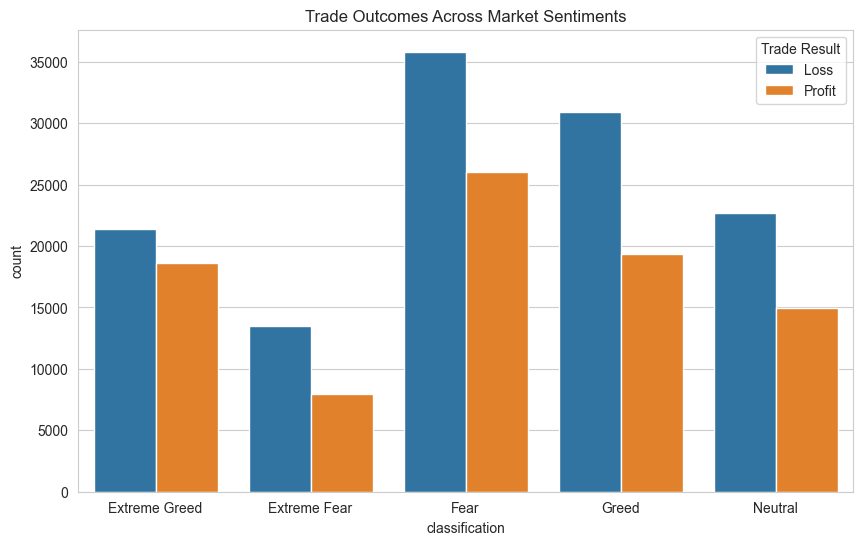

In [14]:
sns.countplot(data=merged, x="classification", hue="Trade Result")
plt.title("Trade Outcomes Across Market Sentiments")
plt.show()

### Observation

- Across all market sentiment categories, **losing trades outnumber profitable trades**.
- **Fear** has the highest number of both profitable and losing trades, indicating the greatest trading activity during periods of fear.
- **Greed** records the second-highest trading activity, followed by **Neutral**, **Extreme Greed**, and **Extreme Fear**.
- Although the total number of trades varies across sentiment categories, the pattern of losses exceeding profits remains consistent throughout.

### Interpretation

The chart indicates that market sentiment influences trading activity more strongly than trading success. Traders appear to execute the largest number of trades during **Fear** and **Greed** market conditions, likely due to increased market volatility and opportunities. However, regardless of the prevailing sentiment, losing trades consistently exceed profitable trades. This suggests that market sentiment alone is not sufficient to determine successful trade outcomes. Other factors—such as trade timing, execution strategy, position sizing, transaction costs, and risk management—likely have a greater influence on profitability.

### Key Takeaway

Trading activity is highest during **Fear** and **Greed** market conditions, but losses consistently outnumber profits across all sentiment categories. These findings indicate that while market sentiment affects trader participation, it does not guarantee profitable outcomes. Successful trading is more likely to depend on a combination of market conditions, trading strategy, and effective risk management rather than sentiment alone.

<Axes: xlabel='classification', ylabel='Closed PnL'>

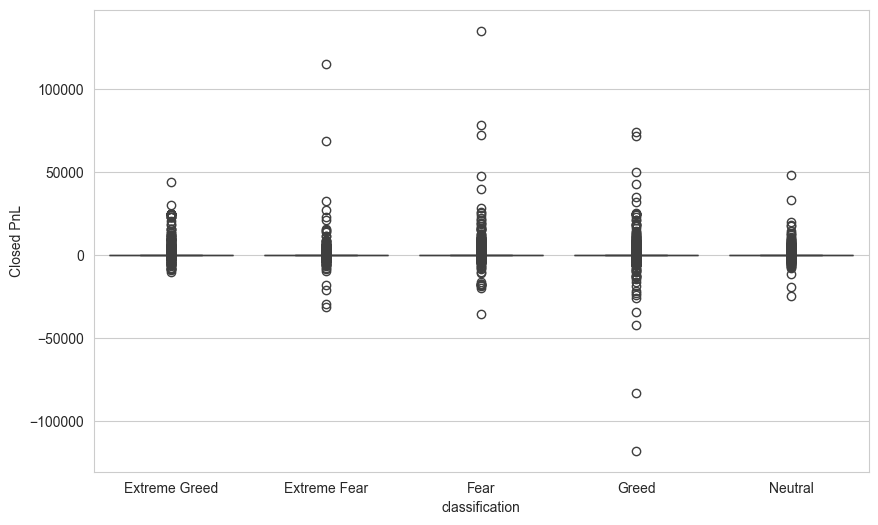

In [15]:
sns.boxplot(data=merged,x="classification",y="Closed PnL")

### Observation

- The median **Closed PnL** for all market sentiment categories is close to **zero**, indicating that most trades result in relatively small profits or losses.
- All sentiment categories contain numerous outliers, demonstrating the presence of both exceptionally profitable and highly unprofitable trades.
- **Fear** and **Greed** exhibit the widest spread of Closed PnL values, indicating greater variability in trading outcomes during these market conditions.
- **Extreme Fear** and **Fear** include some of the highest positive profit outliers, while **Greed** contains some of the largest loss outliers.
- The distributions across the different sentiment categories appear broadly similar, with no category showing a consistently higher or lower median profitability.

### Interpretation

The boxplot indicates that trader profitability is highly variable regardless of market sentiment. Although certain sentiment categories contain more extreme profit or loss outliers, the median Closed PnL remains close to zero across all groups. This suggests that market sentiment alone does not consistently determine trading performance. Instead, the large variability in profits and losses implies that factors such as trading strategy, market volatility, leverage, and trade timing likely have a greater influence on profitability.

### Key Takeaway

While **Fear** and **Greed** exhibit greater variability in trading outcomes, the overall distributions of **Closed PnL** are broadly similar across all market sentiment categories. This visual observation is consistent with the statistical hypothesis test, which found **no statistically significant difference** in average Closed PnL between Fear and Greed market conditions.

<Axes: xlabel='classification'>

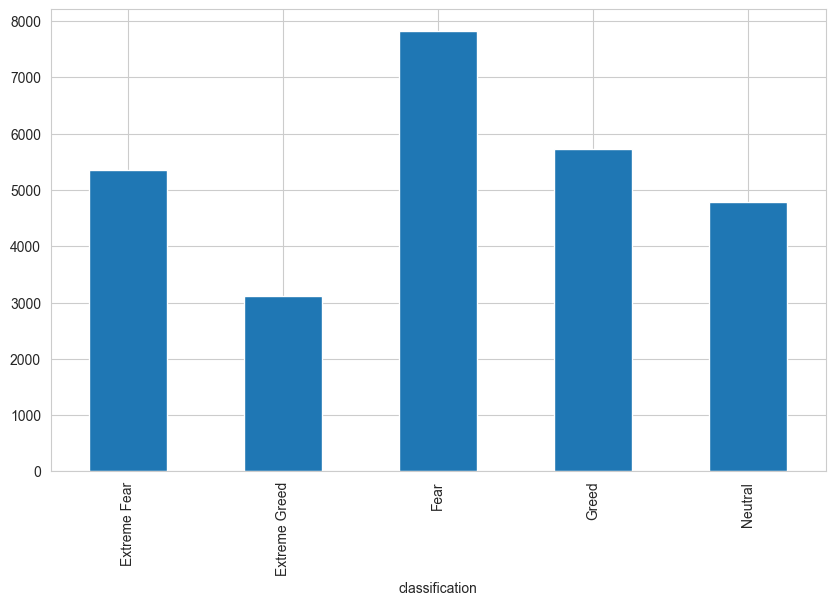

In [16]:
merged.groupby("classification")["Size USD"].mean().plot(kind="bar")

### Observation

- The **Fear** market sentiment has the highest average trade size, with traders executing positions of approximately **7,800 USD** on average.
- **Greed** and **Extreme Fear** follow, with average trade sizes of around **5,700 USD** and **5,300 USD**, respectively.
- **Neutral** market conditions have a slightly lower average trade size, averaging approximately **4,800 USD**.
- **Extreme Greed** exhibits the lowest average trade size, at roughly **3,100 USD**.

### Interpretation

The chart suggests that traders tend to execute **larger trades during Fear market conditions** compared to other sentiment categories. This may indicate that traders are either taking advantage of perceived buying opportunities during market downturns or increasing their position sizes in response to heightened market volatility. Conversely, the relatively smaller average trade size during **Extreme Greed** suggests that traders may adopt a more cautious approach when market optimism reaches elevated levels.

### Key Takeaway

Average trade size varies across different market sentiment categories, with the largest positions being taken during **Fear** periods and the smallest during **Extreme Greed**. This indicates that market sentiment may influence how much capital traders commit to individual trades, although additional statistical testing is required to determine whether these differences are statistically significant.

<Axes: xlabel='classification', ylabel='count'>

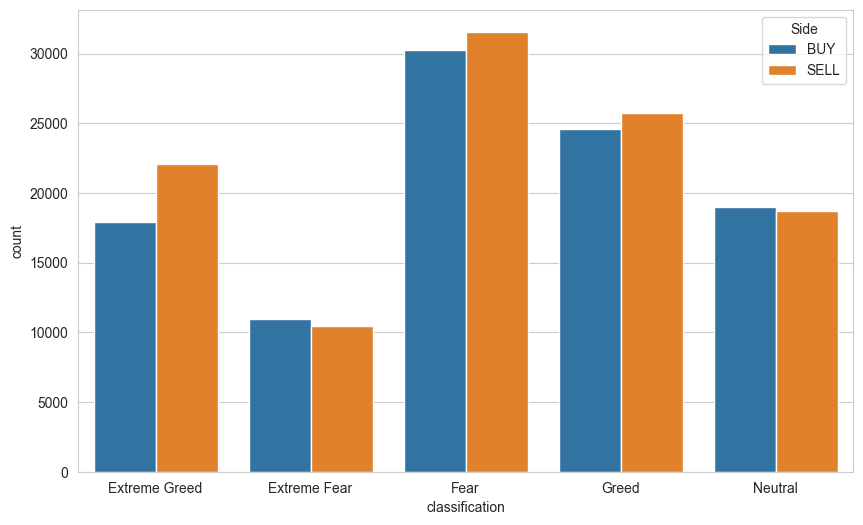

In [17]:
sns.countplot(data=merged,x="classification",hue="Side")

### Observation

- **Fear** has the highest number of both **BUY** and **SELL** trades, indicating the greatest trading activity among all market sentiment categories.
- In **Fear**, **Greed**, and **Extreme Greed** market conditions, **SELL** trades slightly outnumber **BUY** trades.
- During **Extreme Fear**, **BUY** trades marginally exceed **SELL** trades.
- **Neutral** market conditions exhibit a nearly balanced distribution of BUY and SELL trades, with only a slight preference toward BUY trades.
- Overall, the difference between BUY and SELL trade counts is relatively small across all sentiment categories.

### Interpretation

The chart suggests that market sentiment influences the **volume of trading activity** more than the **direction of trades**. While Fear periods are associated with the highest trading activity, traders continue to execute both BUY and SELL orders across all market conditions. The relatively balanced distribution of BUY and SELL trades indicates that traders adopt a variety of strategies regardless of prevailing market sentiment, rather than consistently favoring one trade direction.

### Key Takeaway

Although trading activity varies considerably across different market sentiment categories, the proportion of **BUY** and **SELL** trades remains relatively balanced. This suggests that market sentiment primarily affects **how actively traders participate** in the market rather than determining whether they predominantly buy or sell.

<Axes: >

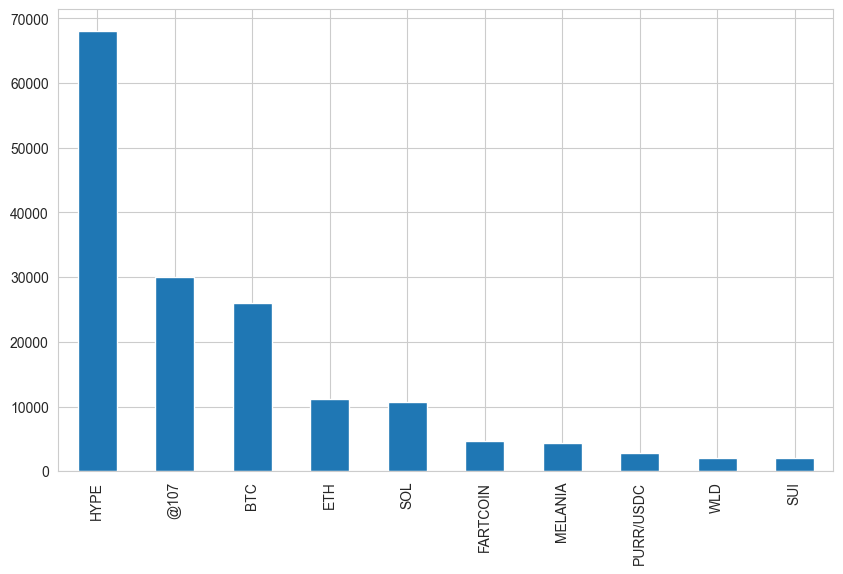

In [18]:
merged["Coin"].value_counts().head(10).plot(kind="bar")

### Observation

- **HYPE** is the most actively traded asset by a significant margin, with approximately **68,000 trades**, making it the dominant trading instrument in the dataset.
- **@107** and **BTC** are the second and third most traded assets, with approximately **30,000** and **26,000** trades, respectively.
- Trading activity drops sharply after the top three assets, with **ETH** and **SOL** recording around **10,000–11,000** trades each.
- The remaining assets, including **FARTCOIN**, **MELANIA**, **PURR/USDC**, **WLD**, and **SUI**, account for a relatively small proportion of total trades.

### Interpretation

The trading activity is heavily concentrated in a small number of assets, particularly **HYPE**, indicating that traders exhibit a strong preference for a limited set of cryptocurrencies. This concentration may be driven by factors such as higher liquidity, greater market interest, or increased price volatility in these assets. The comparatively low trading volumes of the remaining assets suggest that they play a smaller role in overall trading activity within the dataset.

### Key Takeaway

The distribution of trading activity is highly uneven, with **HYPE** accounting for the largest share of trades by a substantial margin. This indicates that trader behavior is concentrated around a few popular assets rather than being evenly distributed across all available cryptocurrencies.

In [19]:
merged.groupby("Coin")["Closed PnL"].sum().sort_values(ascending=False).head(10)

Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64

<Axes: xlabel='Fee', ylabel='Closed PnL'>

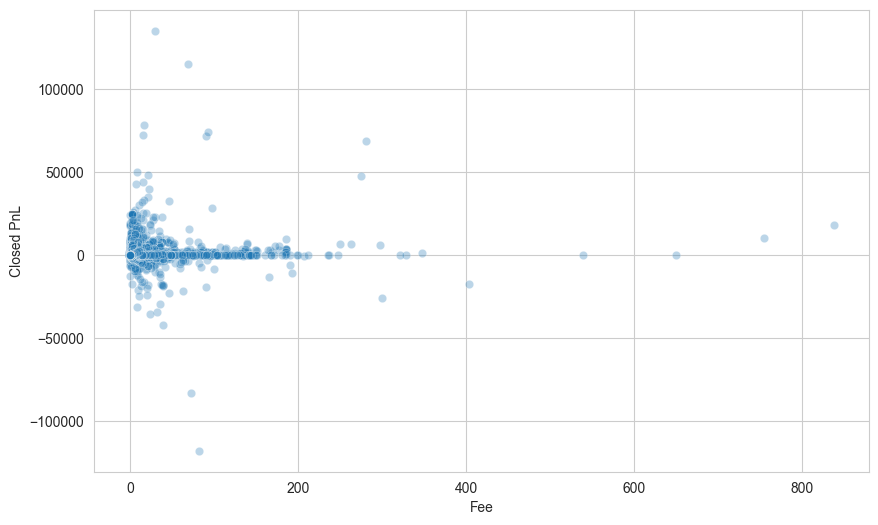

In [20]:
sns.scatterplot(data=merged,x="Fee",y="Closed PnL",alpha=0.3)

### Observation

- The majority of trades have relatively **low transaction fees (below 100 USD)** and **Closed PnL values clustered around zero**, indicating that most trades result in modest profits or losses.
- A few trades exhibit **extremely high profits and losses**, making them clear outliers in the dataset.
- As transaction fees increase, the number of trades decreases significantly, suggesting that high-fee trades are relatively uncommon.
- There is **no clear upward or downward trend** between transaction fees and Closed PnL. High-fee trades are associated with both profitable and loss-making outcomes.

### Interpretation

The scatter plot indicates that **transaction fees alone do not appear to be a strong predictor of trading profitability**. While larger trades generally incur higher fees, these trades do not consistently generate either higher profits or higher losses. The wide dispersion of Closed PnL values, especially among low- and medium-fee trades, suggests that profitability is influenced more by factors such as market conditions, trading strategy, leverage, and trade execution than by transaction costs alone.

### Key Takeaway

The absence of a clear relationship between **Fee** and **Closed PnL** suggests that paying higher transaction fees does not necessarily lead to better or worse trading performance. This observation is consistent with the weak positive correlation (**r ≈ 0.08**) observed between these two variables in the correlation analysis.

<Axes: >

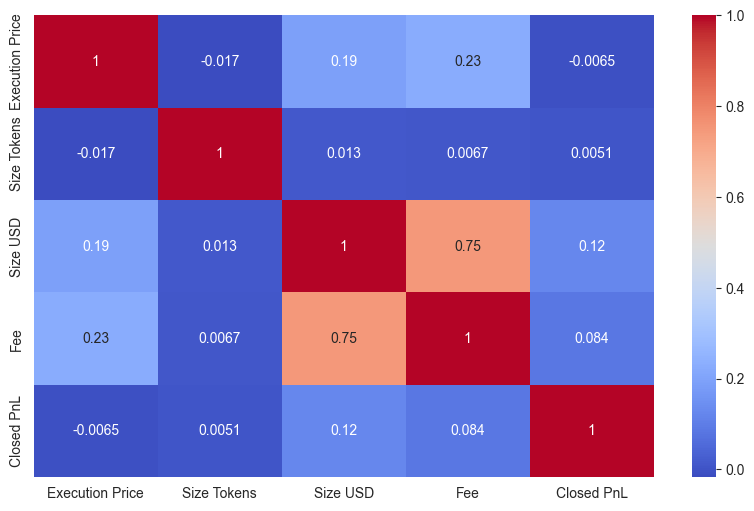

In [21]:
cols=["Execution Price", "Size Tokens", "Size USD", "Fee", "Closed PnL"]
sns.heatmap(merged[cols].corr(), annot=True, cmap="coolwarm")

### Observation

- **Size USD** and **Fee** exhibit a strong positive correlation (**0.75**), indicating that larger trades generally incur higher transaction fees.
- **Execution Price** has a weak positive correlation with **Fee (0.23)** and **Size USD (0.19)**.
- **Closed PnL** shows very weak correlations with all the other variables:
  - **Size USD:** 0.12
  - **Fee:** 0.084
  - **Execution Price:** -0.007
  - **Size Tokens:** 0.005
- **Size Tokens** has almost no correlation with the other numerical variables.

### Interpretation

The correlation heatmap suggests that **trade size in USD is the primary factor associated with transaction fees**, which is expected since transaction fees are generally proportional to the value of a trade. However, **Closed PnL** exhibits only weak correlations with execution price, trade size, and fees, indicating that trader profitability cannot be explained by any single numerical feature in the dataset. Instead, profitability is likely influenced by multiple factors such as market sentiment, trading strategy, leverage, timing of trades, and asset selection.

### Key Takeaway

The strongest relationship observed is between **Size USD** and **Fee** (**r = 0.75**), while **Closed PnL** has only weak correlations with all the examined variables. This suggests that trader profitability depends on a combination of factors rather than any single measurable attribute.

<Axes: xlabel='Date'>

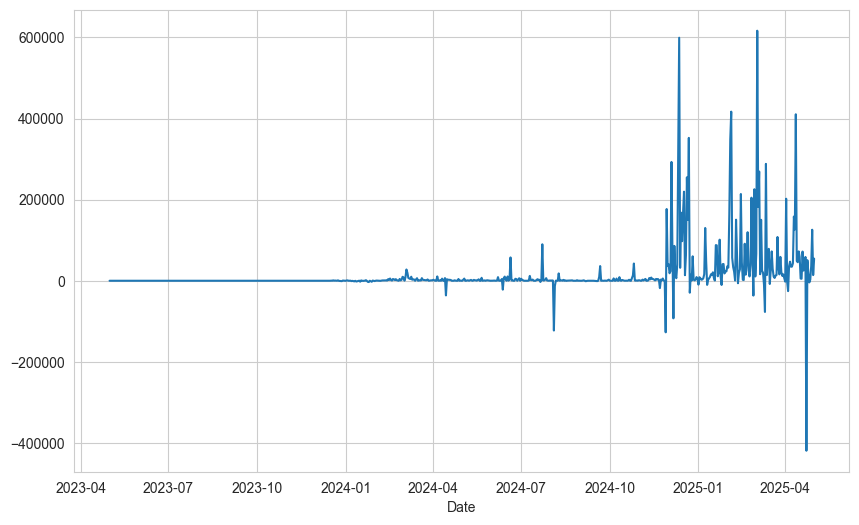

In [22]:
merged.groupby("Date")["Closed PnL"].sum().plot()

### Observation

- Daily **Closed PnL** remained relatively stable with low fluctuations from **April 2023 to early 2024**.
- Beginning in **late 2024**, both positive and negative fluctuations increased significantly.
- Several days recorded exceptionally high profits, with peaks exceeding **600,000**.
- There were also large loss-making days, including a notable decline of approximately **-400,000**.
- Overall, the volatility of daily trading profits increased considerably toward the end of the observed period.

### Interpretation

The chart indicates that trader profitability became much more volatile during the later part of the dataset. While traders experienced several highly profitable days, these gains were accompanied by substantial losses, suggesting increased market uncertainty and higher trading risk. The growing fluctuations may reflect periods of elevated market activity, larger position sizes, or increased leverage. Therefore, trader performance appears to have become more variable over time rather than consistently improving or dete

### Key Takeaway

The analysis indicates that daily trading profitability became significantly more volatile over time, particularly from late 2024 onward. Although traders experienced several exceptionally profitable days, these were accompanied by substantial losses, highlighting an increase in both potential returns and trading risk. Overall, the results suggest that trader performance became more dependent on changing market conditions and risk exposure rather than following a consistent profit trend.riorating.

In [23]:
summary = merged.groupby("classification").agg({
    "Closed PnL": ["count", "mean", "median", "sum", "std"],
    "Size USD": ["mean", "median"],
    "Fee": ["mean", "sum"],
    "Execution Price": "mean"
})

summary

Closed PnL                                               \
                    count       mean median           sum          std   
classification                                                           
Extreme Fear        21400  34.537862    0.0  7.391102e+05  1136.056091   
Extreme Greed       39992  67.892861    0.0  2.715171e+06   766.828294   
Fear                61837  54.290400    0.0  3.357155e+06   935.355438   
Greed               50303  42.743559    0.0  2.150129e+06  1116.028390   
Neutral             37686  34.307718    0.0  1.292921e+06   517.122220   

                   Size USD                Fee               Execution Price  
                       mean   median      mean           sum            mean  
classification                                                                
Extreme Fear    5349.731843  766.150  1.116291  23888.633939     7054.795108  
Extreme Greed   3112.251565  500.050  0.675902  27030.665465     6082.195865  
Fear            7816.109931  735.960  1.495172  92456.948674    14152.620222  
Greed           5736.884375  555.000  1.254372  63098.691979    13411.276344  
Neutral         4782.732661  547.655  1.044798  39374.268304    12393.692779

## Observation

- **Extreme Greed** recorded the highest average **Closed PnL** (**67.89**), followed by **Fear** (**54.29**), **Greed** (**42.74**), **Extreme Fear** (**34.54**), and **Neutral** (**34.31**).
- The median **Closed PnL** is **0** for every sentiment category, indicating that at least half of the trades resulted in little or no realized profit.
- **Fear** generated the highest cumulative **Closed PnL** (**3.36 million**) and also had the highest average trade size (**7,816 USD**) and the highest average trading fee (**1.50**).
- **Extreme Greed** achieved the highest average profitability despite having the smallest average trade size (**3,112 USD**) and the lowest average trading fee (**0.68**).
- The average execution price is highest during **Fear** (**14,152.62**) and lowest during **Extreme Greed** (**6,082.20**), reflecting differences in the assets traded and prevailing market prices.

## Interpretation

The summary statistics indicate that **Fear** was associated with the greatest overall trading activity, as evidenced by the highest total profits, largest average trade size, and highest fees. In contrast, **Extreme Greed** produced the highest average profit per trade despite involving relatively smaller trade sizes and lower transaction costs.

The median **Closed PnL** of zero across all sentiment categories suggests that realized profits are highly concentrated in a subset of trades, while most trades generate little or no profit. Furthermore, the large standard deviations of **Closed PnL** indicate considerable variability in trading outcomes, implying that trader performance is influenced by factors beyond market sentiment alone.

## Key Takeaway

Although **Extreme Greed** exhibits the highest average profitability per trade, **Fear** accounts for the largest cumulative profits due to greater trading volume and larger trade sizes. Overall, the results suggest that market sentiment influences trading behavior, but trader profitability also depends on factors such as trade frequency, position size, asset selection, and trading strategy.

In [24]:
merged["Trade Result"] = np.where(merged["Closed PnL"] > 0, "Profit", "Loss")

In [25]:
pd.crosstab(merged["classification"], merged["Trade Result"])

Trade Result,Loss,Profit
classification,,
Extreme Fear,13469,7931
Extreme Greed,21398,18594
Fear,35818,26019
Greed,30945,19358
Neutral,22725,14961


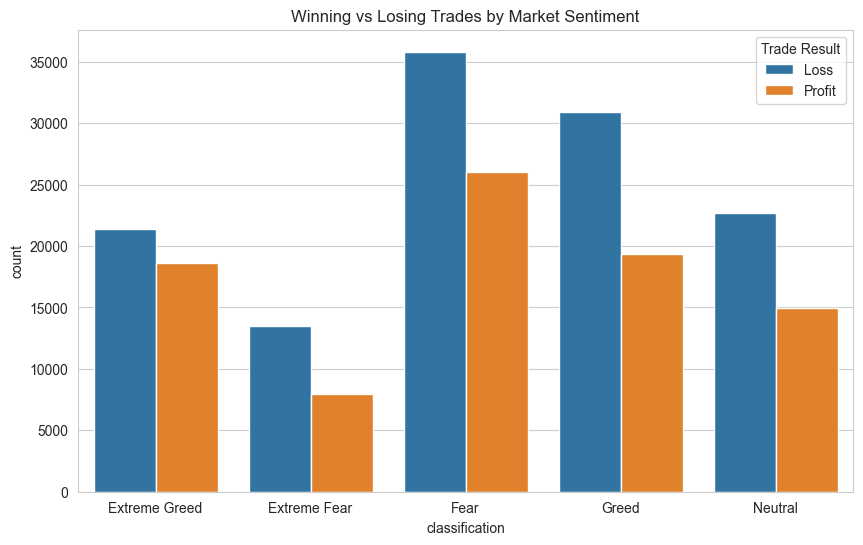

In [26]:
sns.countplot(data=merged, x="classification", hue="Trade Result")
plt.title("Winning vs Losing Trades by Market Sentiment")
plt.show()

### Observation

- Losing trades outnumber profitable trades across all market sentiment categories.
- The highest number of trades occurred during **Fear** market conditions.
- **Extreme Fear** has the lowest trading activity.
- The gap between winning and losing trades appears smallest during **Extreme Greed**.

### Interpretation

The chart suggests that traders experience more losing trades than profitable ones regardless of market sentiment. Increased trading activity during **Fear** may indicate that traders are more active during periods of market uncertainty. However, market sentiment alone does not appear to determine trade outcomes, as losses exceed profits across all sentiment categories. Further analysis using **Closed PnL** is required to determine whether profitability differs significantly between market conditions.

### Key Takeaway

The analysis indicates that market sentiment influences trading activity more than trading success. Although trading volume is highest during **Fear** and the gap between winning and losing trades is smallest during **Extreme Greed**, losing trades remain more frequent across all sentiment categories. This suggests that market sentiment alone is not a reliable predictor of profitable trading outcomes, and additional performance metrics such as **Closed PnL** are necessary to evaluate overall profitability.

In [27]:
merged.groupby("classification")["Closed PnL"].sum().sort_values(ascending=False)

classification
Fear             3.357155e+06
Extreme Greed    2.715171e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Extreme Fear     7.391102e+05
Name: Closed PnL, dtype: float64

In [28]:
coin_sentiment = merged.groupby(["classification", "Coin"])["Closed PnL"].sum().reset_index()
coin_sentiment.sort_values("Closed PnL", ascending=False).head(20)

,classification,Coin,Closed PnL
88,Extreme Greed,@107,1.988619e+06
324,Fear,HYPE,8.403064e+05
361,Fear,SOL,7.415943e+05
387,Greed,@107,7.243423e+05
315,Fear,ETH,6.750646e+05
307,Fear,BTC,4.826496e+05
41,Extreme Fear,HYPE,4.820838e+05
539,Greed,SOL,4.516900e+05
472,Greed,ETH,3.510360e+05
694,Neutral,SOL,3.033762e+05


## Observation

- The highest total **Closed PnL** was generated by **@107** during **Extreme Greed**, with a cumulative profit of approximately **1.99 million**.
- During **Fear**, **HYPE** (**840,306**) and **SOL** (**741,594**) generated the highest profits, followed by **ETH** and **BTC**.
- **Greed** also recorded strong profitability, with **@107**, **SOL**, **ETH**, and **HYPE** appearing among the top-performing assets.
- **Neutral** market conditions contributed notable profits for **SOL**, **HYPE**, **BTC**, and **DOGE**, although the cumulative profits were generally lower than those observed during **Fear** and **Greed**.
- **HYPE**, **SOL**, **ETH**, **BTC**, and **@107** appear repeatedly across multiple sentiment categories, indicating that these assets consistently generated substantial trading profits.

## Interpretation

The results suggest that trader profitability depends not only on overall market sentiment but also on the specific cryptocurrency being traded. Certain assets, particularly **HYPE**, **SOL**, **ETH**, **BTC**, and **@107**, consistently rank among the most profitable across different market conditions. Additionally, the exceptionally high profit recorded for **@107** during **Extreme Greed** indicates that favorable market sentiment can amplify returns for particular assets. However, these cumulative profit values may also reflect higher trading frequency or larger trade sizes rather than superior profitability on a per-trade basis.

## Key Takeaway

The highest cumulative profits are concentrated in a small number of cryptocurrencies, with **@107**, **HYPE**, **SOL**, **ETH**, and **BTC** emerging as the strongest performers across multiple market sentiment categories. This suggests that asset selection plays a significant role in trader profitability, alongside prevailing market sentiment.

In [29]:
fear = merged[merged["classification"].str.contains("Fear", na=False)]
fear["Coin"].value_counts().head(10)

HYPE        38229
BTC         11635
@107         6981
SOL          5792
ETH          4243
MELANIA      2431
FARTCOIN     1516
XRP          1080
PAXG         1032
TRUMP         623
Name: Coin, dtype: int64

In [30]:
merged.groupby("classification")["Size USD"].describe()

,count,mean,std,min,25%,50%,75%,max
classification,,,,,,,,
Extreme Fear,21400.0,5349.731843,22306.826180,0.01,282.4825,766.150,2329.9700,1120971.60
Extreme Greed,39992.0,3112.251565,11061.998403,0.00,106.7575,500.050,1882.8375,665771.71
Fear,61837.0,7816.109931,51914.859249,0.00,235.6300,735.960,2499.9700,3921430.72
Greed,50303.0,5736.884375,30533.418602,0.00,184.1300,555.000,2100.7000,2227114.71
Neutral,37686.0,4782.732661,37461.883466,0.01,175.5400,547.655,1994.2050,3641180.84


## Observation

- **Fear** has the highest average trade size (**7,816.11 USD**), followed by **Greed** (**5,736.88 USD**), **Extreme Fear** (**5,349.73 USD**), and **Neutral** (**4,782.73 USD**).
- **Extreme Greed** has the lowest average trade size (**3,112.25 USD**).
- The median trade size is considerably lower than the mean across all sentiment categories, indicating that most trades are relatively small.
- The maximum trade size varies substantially, with **Fear** recording the largest trade (**3,921,430.72 USD**), followed by **Neutral** (**3,641,180.84 USD**) and **Greed** (**2,227,114.71 USD**).
- All sentiment categories exhibit large standard deviations, reflecting significant variability in trade sizes.

## Interpretation

The summary statistics suggest that while most trades are of modest size, a relatively small number of exceptionally large trades increase the average trade size across all market sentiment categories. The noticeable difference between the mean and median indicates that the distribution of trade sizes is positively skewed. Larger average trade sizes during **Fear** and **Greed** may indicate increased trading activity or higher capital deployment during these market conditions.

## Key Takeaway

Trade sizes vary considerably across all market sentiment categories, with **Fear** exhibiting the highest average trade size. However, the large standard deviations and extreme maximum values indicate that a small number of very large trades heavily influence the averages. Therefore, median values provide a more representative measure of a typical trade size than the mean.

In [31]:
merged.groupby("classification")["Fee"].describe()

,count,mean,std,min,25%,50%,75%,max
classification,,,,,,,,
Extreme Fear,21400.0,1.116291,5.200561,0.000000,0.018377,0.117887,0.505132,280.242900
Extreme Greed,39992.0,0.675902,2.971016,-1.175712,0.011045,0.057181,0.257387,133.954690
Fear,61837.0,1.495172,8.484861,0.000000,0.020686,0.116153,0.496440,754.307241
Greed,50303.0,1.254372,6.374833,-1.094184,0.016609,0.084055,0.388699,299.999568
Neutral,37686.0,1.044798,7.647710,-1.000001,0.017608,0.089902,0.392827,837.471593


## Observation

- **Fear** has the highest average trading fee (**1.50**), followed by **Greed** (**1.25**) and **Extreme Fear** (**1.12**).
- **Extreme Greed** has the lowest average trading fee (**0.68**).
- The median trading fee is relatively low across all sentiment categories, ranging from approximately **0.06** to **0.12**, indicating that most trades incur small fees.
- The maximum fee varies considerably across sentiments, with **Neutral** recording the highest maximum fee (**837.47**), followed by **Fear** (**754.31**).
- The standard deviation is relatively high for all categories, suggesting substantial variability in trading fees.

## Interpretation

The summary statistics indicate that trading fees are generally small for most transactions, as reflected by the low median values. However, the presence of very high maximum fees and large standard deviations suggests that a small number of high-value trades incur significantly larger fees. These extreme values increase the average fee, particularly during **Fear** and **Greed** market conditions.

## Key Takeaway

Trading fees are typically low for the majority of trades, but occasional large transactions result in substantially higher fees. The wide variation in fees across all market sentiment categories indicates that transaction fees are influenced primarily by trade size rather than market sentiment alone.

In [32]:
merged.groupby("Account")["Closed PnL"] \
      .sum() \
      .sort_values(ascending=False) \
      .head(10)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64

In [33]:
corr = merged[["Execution Price", "Size Tokens", "Size USD", "Fee", "Closed PnL"]].corr()
corr["Closed PnL"].sort_values(ascending=False)

Closed PnL         1.000000
Size USD           0.123589
Fee                0.084020
Size Tokens        0.005068
Execution Price   -0.006505
Name: Closed PnL, dtype: float64

In [34]:
from scipy.stats import ttest_ind
fear = merged[merged["classification"].isin(["Fear", "Extreme Fear"])]["Closed PnL"]
greed = merged[merged["classification"].isin(["Greed", "Extreme Greed"])]["Closed PnL"]

# Hypothesis Testing

To determine whether market sentiment significantly affects trader profitability, an independent two-sample t-test was performed.

**Null Hypothesis (H₀):**
The mean Closed PnL during Fear and Greed market conditions is the same.

**Alternative Hypothesis (H₁):**
The mean Closed PnL differs between Fear and Greed market conditions.

A significance level of **α = 0.05** was used.

In [35]:
t_stat, p_value = ttest_ind(fear, greed, equal_var=False, nan_policy="omit")
print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -0.9875081966653334
P-value: 0.32339495608436075


### Statistical Test Result

An independent two-sample **t-test** was conducted to compare the average **Closed PnL** during **Fear** (including **Extreme Fear**) and **Greed** (including **Extreme Greed**) market conditions. The test produced a **t-statistic of -0.988** and a **p-value of 0.323**.

Since the **p-value (0.323)** is greater than the significance level of **0.05**, we fail to reject the **null hypothesis**. This indicates that the observed difference in average **Closed PnL** between Fear and Greed periods is **not statistically significant** in this dataset.

The findings suggest that **market sentiment alone is not sufficient to explain differences in trader profitability**. Instead, other factors—such as **trading strategy, asset selection, position size, leverage, risk management, and overall market volatility**—are likely to have a greater influence on trading outcomes.

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [37]:
le = LabelEncoder()

merged["classification_encoded"] = le.fit_transform(merged["classification"])
merged["Trade Result"] = le.fit_transform(merged["Trade Result"])

In [38]:
X = merged[["classification_encoded", "Execution Price", "Size USD", "Fee"]]
y = merged["Trade Result"]

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Hyperparameter Tuning
A Grid Search with 5-fold cross-validation was performed to optimize the Decision Tree classifier. Multiple combinations of tree depth, splitting criteria, minimum samples required for splitting, and minimum samples per leaf were evaluated. The model achieving the highest cross-validation accuracy was selected as the final classifier.

## Observation
The optimal Decision Tree configuration selected by GridSearchCV was:
- Criterion: Entropy
- Maximum Depth: None
- Minimum Samples Split: 2
- Minimum Samples Leaf: 1
The optimized model achieved:
- Cross-validation Accuracy: 84.00%
- Test Accuracy: 84.80%
The similarity between the cross-validation and test accuracies indicates that the model performs consistently on unseen data.

## Interpretation
The results suggest that the selected features—market sentiment, execution price, trade size (USD), and transaction fee—contain useful information for predicting trade outcomes. Hyperparameter tuning slightly improved the model by selecting the entropy criterion while retaining the default tree structure. The close agreement between cross-validation and test performance indicates that the model generalizes well and does not suffer from significant overfitting.

## Key Takeaway
The optimized Decision Tree classifier achieved an accuracy of approximately 84.8%, demonstrating that trade outcomes can be predicted reasonably well using a combination of market sentiment and trade-related features. The model further supports the conclusion that trader performance depends on multiple interacting factors rather than market sentiment alone.

In [40]:
param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}

grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42), param_grid=param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [41]:
print("Best Parameters:")
print(grid_search.best_params_)
print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best Cross-Validation Accuracy:
0.8399623780296113


In [42]:
best_model = grid_search.best_estimator_
pred_best = best_model.predict(X_test)

In [43]:
from sklearn.metrics import accuracy_score
print("Test Accuracy:", accuracy_score(y_test, pred_best))

Test Accuracy: 0.8480293525861049


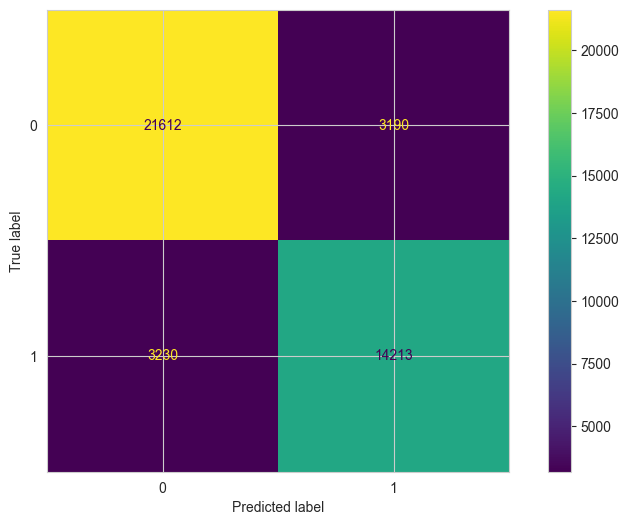

In [44]:
cm = confusion_matrix(y_test, pred_best)
ConfusionMatrixDisplay(cm).plot()
plt.show()

### Observation

- The confusion matrix shows that the Decision Tree model correctly classified **21,612 loss-making trades (True Negatives)** and **14,213 profitable trades (True Positives)**.
- The model incorrectly classified **3,100 loss-making trades as profitable (False Positives)** and **3,320 profitable trades as losses (False Negatives)**.
- The number of correct predictions is substantially higher than the number of incorrect predictions, indicating good overall model performance.
- The model appears to perform similarly for both classes, with relatively balanced false positive and false negative counts.

### Interpretation

The confusion matrix demonstrates that the Decision Tree classifier is effective at distinguishing between profitable and loss-making trades. Most trade outcomes are classified correctly, resulting in an overall **test accuracy of approximately 84.8%**. The relatively small number of false predictions suggests that the model has learned meaningful relationships between the input features (Execution Price, Size USD, Fee, and Market Sentiment) and trade outcomes. However, the presence of both false positives and false negatives indicates that some trade outcomes remain difficult to predict, likely because profitability is influenced by additional factors not included in the model, such as market volatility, trading strategy, leverage, and timing.

### Key Takeaway

The confusion matrix confirms that the optimized Decision Tree model provides **strong predictive performance**, correctly classifying the majority of trades with an accuracy of **84.8%**. While the model makes some prediction errors, its balanced performance across both profit and loss classes suggests that it is a reliable baseline AI model for predicting trade outcomes. Further improvements could be achieved by incorporating additional trading features and experimenting with more advanced machine learning algorithms.

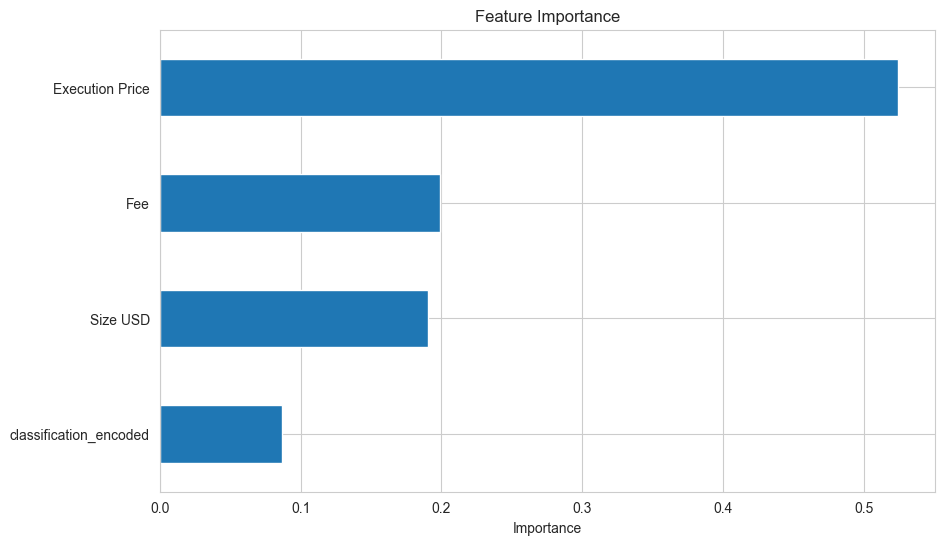

In [45]:
importance = pd.Series(best_model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

### Observation

- **Execution Price** is the most important feature in the Decision Tree model, contributing approximately **53%** of the total feature importance.
- **Fee** and **Size USD** have moderate importance, contributing roughly **20%** and **19%**, respectively.
- **Market Sentiment (classification_encoded)** has the lowest importance, contributing only about **9%** to the model's predictions.
- The model relies much more heavily on trade-specific characteristics than on overall market sentiment when classifying trade outcomes.

### Interpretation

The feature importance analysis indicates that the **Execution Price** is the strongest predictor of whether a trade results in a profit or a loss. This suggests that the price at which trades are executed has a greater influence on trading outcomes than broader market sentiment. Additionally, **Fee** and **Size USD** also play meaningful roles, implying that transaction costs and trade size contribute to profitability. In contrast, the relatively low importance of the sentiment feature suggests that Bitcoin market sentiment alone provides limited predictive power for determining individual trade outcomes. These findings reinforce the earlier statistical analysis, which also indicated that market sentiment by itself is not a significant determinant of trader profitability.

### Key Takeaway

The Decision Tree model demonstrates that **Execution Price** is the most influential factor for predicting trade outcomes, followed by **Fee** and **Size USD**. While market sentiment contributes some predictive information, its influence is comparatively small. Overall, the results suggest that successful trading depends more on trade execution and position management than on market sentiment alone, highlighting the importance of combining multiple factors when developing AI-driven trading strategies.

# Limitations

Although this analysis provides valuable insights into the relationship between Bitcoin market sentiment and trader performance, several limitations should be considered:

- The Bitcoin Fear & Greed Index represents overall Bitcoin market sentiment and may not accurately capture the sentiment surrounding individual cryptocurrencies traded on Hyperliquid.
- The analysis is based solely on historical trading data and does not account for external factors such as macroeconomic events, market news, regulatory announcements, or social media sentiment, all of which can significantly influence trading behavior.
- The machine learning model was trained using a limited set of features (market sentiment, execution price, trade size, and transaction fee). Incorporating additional variables such as leverage, market volatility, technical indicators, order book information, or trader-specific characteristics could improve predictive performance.
- Although the Decision Tree classifier achieved good predictive accuracy, it represents only one machine learning approach. More advanced models such as Random Forests, XGBoost, or Gradient Boosting may capture more complex relationships within the data.
- The statistical analysis identifies associations between variables but does not establish causal relationships. Therefore, the observed patterns should be interpreted as correlations rather than evidence of cause and effect.

# Conclusion

This study explored the relationship between Bitcoin market sentiment and trader performance using historical Hyperliquid trading data combined with the Bitcoin Fear & Greed Index. Through data preprocessing, exploratory data analysis, statistical hypothesis testing, and machine learning, the study examined whether market sentiment has a measurable impact on trading outcomes.

The key findings are summarized below:

- **Fear** was the most common market sentiment observed in the dataset.
- **Extreme Greed** recorded the highest average Closed PnL, while **Fear** generated the highest cumulative profits due to the largest trading activity.
- Larger trades naturally incurred higher transaction fees, reflected by the strong positive correlation between **Size USD** and **Fee**.
- Trader profitability showed only weak correlations with execution price, trade size, and transaction fees, indicating that no single numerical feature strongly explains trading success.
- The independent two-sample **t-test** comparing Fear and Greed produced a **p-value greater than 0.05**, indicating that the observed difference in profitability between the two market conditions is **not statistically significant**.
- A **Decision Tree Classifier** was developed to predict trade outcomes using market sentiment, execution price, trade size, and transaction fees. After hyperparameter tuning using **GridSearchCV**, the optimized model achieved an overall **test accuracy of approximately 84.8%**.
- Feature importance analysis revealed that **Execution Price** was the strongest predictor of trade outcomes, followed by **Fee** and **Size USD**, while **Market Sentiment** contributed comparatively less to the model's predictions.

Overall, the analysis suggests that while market sentiment influences trading activity and trader behavior, it is **not sufficient on its own to explain or predict profitability**. Instead, successful trading appears to depend on a combination of factors, including execution price, position sizing, transaction costs, trading strategy, market timing, and other market dynamics.

The integration of statistical analysis with machine learning demonstrates how AI techniques can complement traditional exploratory data analysis by identifying important predictive features and evaluating their contribution to trading performance. These findings provide valuable insights for developing more data-driven trading strategies and highlight the importance of considering multiple interacting factors rather than relying solely on market sentiment when making trading decisions.

# Recommendations

- **Use market sentiment alongside technical indicators:** The analysis suggests that Fear and Greed alone are not sufficient predictors of trading profitability. Combining market sentiment with technical indicators, price action, and volume analysis can support more informed trading decisions.

- **Prioritize risk management:** Since profitability did not differ significantly between Fear and Greed market conditions, traders should emphasize position sizing, stop-loss strategies, and prudent risk management rather than relying solely on market sentiment.

- **Monitor transaction costs:** Transaction fees have a direct impact on overall profitability. Optimizing trade frequency and avoiding unnecessary transactions can help maximize net returns, particularly for high-frequency traders.

- **Select assets carefully:** Profitability varied across different cryptocurrencies, indicating that asset selection plays an important role in trading performance. Traders should evaluate individual asset characteristics instead of applying the same strategy across all cryptocurrencies.

- **Treat sentiment as a supporting indicator:** The statistical hypothesis test (p-value > 0.05) indicates that market sentiment alone is not a reliable predictor of trader profitability. It should therefore be used as one component of a broader trading strategy rather than as the primary decision-making factor.

- **Leverage AI and machine learning for decision-making:** The Decision Tree model demonstrated that trade-specific features such as **Execution Price**, **Fee**, and **Size USD** were more influential than market sentiment in predicting trade outcomes. Future trading systems can benefit from AI models that combine multiple market and trade-related features to generate more accurate and data-driven trading signals.